## **SNAP Jupyter demo notebook**
**Run a simple SNAP workflow in different ways using SNAP/Python APIs...**

In summary, this workflow contains:

- Read a S2A_MSIL1C data product
- Briefly explore the product
- Run a simple SNAP workflow (Read, Subset, BandMath (NDVI)) in three ways:
  - use the Java-Python mapping provided by Snappy
  - use SNAP GPF operators with Snappy
  - create and execute a SNAP GPF xml graph using SNAPISTA

Complexity: intermediate

##### ***Some information on the Python environment:***

In [30]:
import os
import sys
print("Python version: " + sys.version)

import sysconfig
print("Location of esa_snappy package: " + sysconfig.get_paths()['purelib'] + os.sep + "esa_snappy")

Python version: 3.13.11 | packaged by Anaconda, Inc. | (main, Dec 10 2025, 21:21:58) [MSC v.1929 64 bit (AMD64)]
Location of esa_snappy package: E:\olaf\miniconda_py313\Lib\site-packages\esa_snappy


##### ***Import Python packages...***

**Note:** The imports of *esa_snappy* and *snapista* may result in various Info/Warning/Error messages from SNAP core or 3rd party modules. They can be ignored here.

In [31]:
# General
import os
import sys
import subprocess
import sysconfig
import requests
import json

# esa_snappy
import esa_snappy

# Snapista
import snapista
from snapista import Graph
from snapista import Operator
from snapista import TargetBand
from snapista import TargetBandDescriptors

---

##### ***Explore the input data product...***

We will below briefly explore the Sentinel-2 L1C input product 'S2A_MSIL1C_20180803T103021_N0500_R108_T32UNE_20230730T062418'. 

Note that this product is not provided in the Jupyter notebook demo repository. It can, for example, be downloaded via
the [Copernicus Browser](https://dataspace.copernicus.eu/browser/?zoom=3&lat=26&lng=0&themeId=DEFAULT-THEME&visualizationUrl=https%3A%2F%2Fsh.dataspace.copernicus.eu%2Fogc%2Fwms%2Fa91f72b5-f393-4320-bc0f-990129bd9e63&datasetId=S2_L2A_CDAS&demSource3D=%22MAPZEN%22&cloudCoverage=30) (registration required). 

Alternatively, a registered user of the Copernicus Data Space Ecosystem (CDSE) could directly integrate a STAC Catalogue search and corresponding S3 download in a Jupyter notebook flow. An example is available [here](https://github.com/bcdev/snap-lps25/blob/main/notebooks/working-area/lps_workflow_example_v1.1.ipynb). It has been demonstrated within a tutorial at the ESA Living Planet Symposium 2025, using the above source product.

A Sentinel-2 Level-1C Collection 1 product provides orthorectified Top-Of-Atmosphere (TOA) reflectance, with sub-pixel multispectral and multitemporal registration accuracy. Technical quality masks are included in the product. Some of the L1C products main characteristics are listed in the table below.

| Name | Level-1C |
|:--------|:--------|
|  High-level Description   | Top-of-atmosphere reflectances in cartographic geometry for 13 spectral bands | 
|  Data Characteristics   |  UTM/WGS84 projection, JPEG2000 image format | 
|  DEM used   |  Copernicus DEM at 30 m  | 
|  Auxiliary Data   |  CAMS, ECMWF  | 
|  Data Volume   |  700 MB (each 100x100 km2)  | 

L1C Products are a compilation of elementary granules of fixed size, within a single orbit. A granule is the minimum indivisible partition of a product (containing all possible spectral bands). For Level-1C and Level-2A, the granules, also called tiles, are 100x100km2 ortho-images in UTM/WGS84 projection. The UTM (Universal Transverse Mercator) system divides the Earth’s surface into 60 zones. Each UTM zone has a vertical width of 6° of longitude and horizontal width of 8° of latitude. Tiles are approximately 700 MB in size. Tiles can be fully or partially covered by image data.

Many more details and further links can be found at:

[https://sentinels.copernicus.eu/sentinel-data-access/sentinel-products/sentinel-2-data-products/collection-1-level-1c](https://sentinels.copernicus.eu/sentinel-data-access/sentinel-products/sentinel-2-data-products/collection-1-level-1c)

The image below shows a visualization (RGB) of the input product in SNAP Desktop. We have a scene with mostly clear skies (few shallow clouds only) showing Hamburg and surrounding area.

<img src="S2A_MSIL1C_20180803T103021_N0206_R108_T32UNE_20180803T142136_RGB.png" alt="JupyterLab web page" style="max-width: 100%; height: auto;" width: auto>

---

### ***A workflow using the SNAP API from Python***

The following simple workflow example reads raster data from two bands (B4 and B8) of the downloaded S2 L1C product, computes/displays a simple NDVI, and saves the NDVI image as png. The SNAP core classes 'ProductIO' and 'Band' are accessed via the SNAP Python API 'Snappy'.

##### ***Some more imports...***

In [32]:
from esa_snappy import ProductIO  
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

##### ***Read the data product into SNAP:***

Info and warning messages can be ignored here.

In [33]:
l1c_product_to_process = os.getcwd() + os.sep + 'data' + os.sep + 'S2A_MSIL1C_20180803T103021_N0500_R108_T32UNE_20230730T062418.SAFE'
p = ProductIO.readProduct(l1c_product_to_process)

##### ***Print some information:***

In [34]:
print('Number of bands: ' + str(p.getNumBands()))

b4 = p.getBand('B4')
w = b4.getRasterWidth()
h = b4.getRasterHeight()
print('Band B4 Raster width: ' + str(b4.getRasterWidth()))
print('Band B4 Raster height: ' + str(b4.getRasterHeight()))
print('Band B4 Wavelength: ' + str(b4.getSpectralWavelength()))
print('Band B4 Spectral bandwidth: ' + str(b4.getSpectralBandwidth()))

b8 = p.getBand('B8')
w = b8.getRasterWidth()
h = b8.getRasterHeight()
print('Band B8 Raster width: ' + str(b8.getRasterWidth()))
print('Band B8 Raster height: ' + str(b8.getRasterHeight()))
print('Band B8 Wavelength: ' + str(b8.getSpectralWavelength()))
print('Band B8 Spectral bandwidth: ' + str(b8.getSpectralBandwidth()))

Number of bands: 163
Band B4 Raster width: 10980
Band B4 Raster height: 10980
Band B4 Wavelength: 665.0
Band B4 Spectral bandwidth: 30.0
Band B8 Raster width: 10980
Band B8 Raster height: 10980
Band B8 Wavelength: 842.0
Band B8 Spectral bandwidth: 115.0


##### ***Consider a 2000x2000 subset covering the center of Hamburg:***

If possible, using a subset of area of interest and required bands is always recommended. Processing full S2 products might be rather time and memory consuming.

In [35]:
xoff = 5001
yoff = 6001
wsub = 2000
hsub = 2000

##### ***Read the raster data into numpy arrays:***

In [36]:
b4_data = np.zeros(wsub * hsub, np.float32)
b4.readPixels(xoff, yoff, wsub, hsub, b4_data)
b4_data.shape = hsub, wsub

b8_data = np.zeros(wsub * hsub, np.float32)
b8.readPixels(xoff, yoff, wsub, hsub, b8_data)
b8_data.shape = hsub, wsub

##### ***Define a convenience function to plot NDVI:***

In [37]:
def plot_ndvi(data):
    fig1, ax1 = plt.subplots()
    ax1.set_title("NDVI")
    ndvi_image = ax1.imshow(data, cmap=mpl.colormaps['gray'], vmin=-0.2, vmax=1)
    fig1.colorbar(ndvi_image)
    return ndvi_image

##### ***Compute NDVI:***

In [38]:
ndvi_data = (b8_data - b4_data) / (b8_data + b4_data)

##### ***Display B4, B8, NDVI data:***

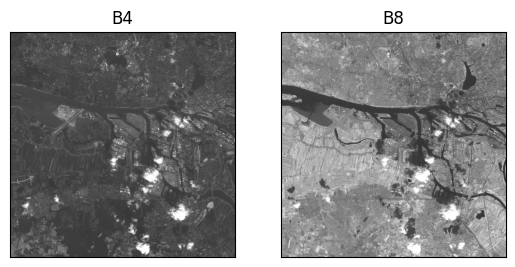

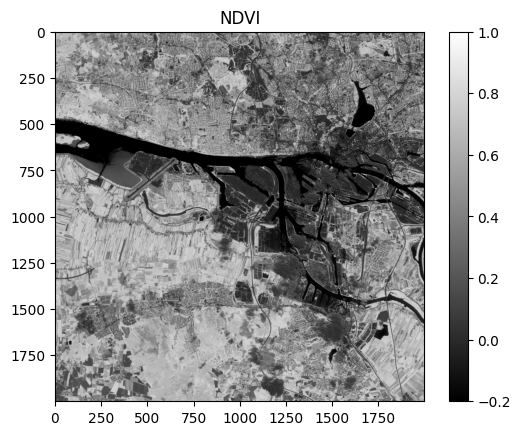

In [39]:
fig, _axs = plt.subplots(nrows=1, ncols=2)
fig.subplots_adjust(hspace=0.5)
axs = _axs.flatten()

axs[0].set_title("B4")
axs[0].tick_params(axis="both", length=0, labelbottom=False, labelleft=False)
axs[0].imshow(b4_data, cmap=mpl.colormaps['gray'], vmin=-0.1, vmax=0.5)

axs[1].set_title("B8")
axs[1].tick_params(axis="both", length=0, labelbottom=False, labelleft=False)
axs[1].imshow(b8_data, cmap=mpl.colormaps['gray'], vmin=-0.1, vmax=0.5)

plt.show(block=True)

ndvi_image = plot_ndvi(ndvi_data)

plt.show()

##### ***Write NDVI to png file:***

In [40]:
ndvi_image.write_png(os.getcwd() + os.sep + 'results' + os.sep + 'snap_nb_comparing_apis_ndvi.png')

##### ***Dispose the product:***

In [41]:
p.dispose()

---

### ***Run the same workflow using GPF and Snappy***

In this section we basically run the same workflow, but with means of the SNAP Python API 'Snappy' together with the SNAP GPF framework.

##### ***Some required imports from esa_snappy:***

In [42]:
from esa_snappy import GPF
from esa_snappy import HashMap
from esa_snappy import Rectangle
from esa_snappy import jpy

##### ***Read L1C product again into SNAP:***

In [43]:
p = ProductIO.readProduct(l1c_product_to_process)

##### ***Set up a 'Subset' operator which considers the rectangle defined above:***

In [44]:
subset_op_name = 'Subset'
subset_parameters = HashMap()
subset_parameters.put('sourceBands', 'B4,B8')
subset_rect = Rectangle(xoff,yoff,wsub,hsub)
subset_parameters.put('region', subset_rect)
subset_product = GPF.createProduct(subset_op_name, subset_parameters, p)

##### ***Set up a 'BandMaths' operator to compute a simple NDVI. Set up a target band for NDVI result:***

In [45]:
bandmaths_op_name = 'BandMaths'
BandDescriptor = jpy.get_type('org.esa.snap.core.gpf.common.BandMathsOp$BandDescriptor')
ndvi_band = BandDescriptor()
ndvi_band.name = 'ndvi'
ndvi_band.type = 'float32'
ndvi_band.expression = '(B8 - B4)/(B8 + B4)'
target_bands = jpy.array('org.esa.snap.core.gpf.common.BandMathsOp$BandDescriptor', 1)
target_bands[0] = ndvi_band
bandmaths_parameters = HashMap()
bandmaths_parameters.put('targetBands', target_bands)
bandmaths_product = GPF.createProduct(bandmaths_op_name, bandmaths_parameters, subset_product)

##### ***Additional step: Merge NDVI with bands of subset product :***

In [46]:
merge_op_name = 'BandMerge'
merge_parameters = HashMap()
merge_parameters.put('sourceBands', 'B4,B8,ndvi')
source_products = HashMap()
source_products.put('Subset', subset_product)
source_products.put('BandMaths', bandmaths_product)
merge_product = GPF.createProduct(merge_op_name, merge_parameters, source_products)

##### ***Additional step: Write Merge Subset result into a NetCDF file. This file can be downloaded and e.g. opened and visualized in SNAP Desktop:***

In [47]:
ProductIO.writeProduct(merge_product, os.getcwd() + os.sep + 'results' + os.sep + './snap_nb_comparing_apis_ndvi_result_snappy.nc', 'NetCDF4-BEAM')

##### ***Display NDVI result:***

We do a quick (visual) check if we have the same NDVI result as from 'pure Snappy' above. 

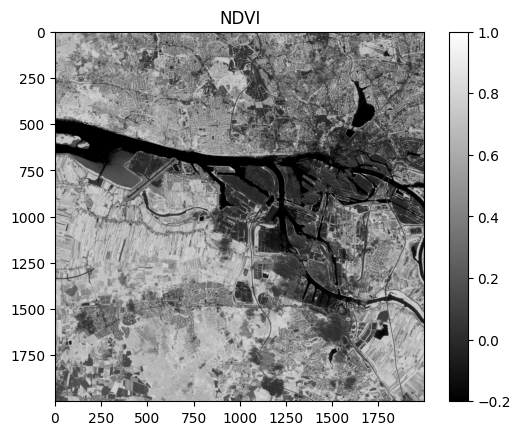

In [48]:
ndvi = merge_product.getBand('ndvi')
w = ndvi.getRasterWidth()
h = ndvi.getRasterHeight()

ndvi_data = np.zeros(w * h, np.float32)
ndvi.readPixels(0, 0, w, h, ndvi_data)
ndvi_data.shape = h, w

ndvi_image = plot_ndvi(ndvi_data)

---

### ***Run the same workflow in an XML graph with SNAPISTA***

In this section we run the same workflow once again, but with means of the SNAP Python API 'SNAPISTA' which since SNAP 12 is provided together with Snappy. The section will illustrate the capabilities of SNAPISTA to create, view, run and export SNAP GPT xml graphs in a very simple and user-friendly manner. 

##### **Fill a SNAPISTA graph with nodes:**


##### ***Initialize the graph:***

In [49]:
try:
    g = Graph()
except Exception as ex:
    print("Cannot set up Snapista Graph():", ex)

##### ***Read L1C product again into SNAP:***

With a single line of Python code, a complete node can be created and added to a GPT graph.

In [50]:
g.add_node(operator=Operator("Read", file=l1c_product_to_process), node_id="Read_l1c")

##### ***Set up a 'Subset' operator which considers the rectangle defined above:***

In [51]:
subset_op = Operator('Subset', sourceBands="B4,B8", region='5001, 6001, 2000, 2000')
g.add_node(operator=subset_op, node_id="Subset" ,source='Read_l1c')

##### ***Set up a 'BandMaths' operator to compute a simple NDVI. Set up a target band for NDVI result:***

In [52]:
band_maths_op = Operator('BandMaths')
ndvi = TargetBand(name='ndvi', expression='(B8 - B4)/(B8 + B4)')
band_maths_op.targetBandDescriptors = TargetBandDescriptors([ndvi])
g.add_node(operator=band_maths_op, node_id="BandMaths" ,source='Subset')

targetBandDescriptors <snapista.target_band_descriptors.TargetBandDescriptors object at 0x0000015F80347C50>
Instance TargetBandDescriptors: True
Instance Aggregators: False
Instance BinningOutputBands: False
Instance BinningVariables: False
Instance str: False


##### ***Merge NDVI with bands of subset product:***

In [53]:
merge = Operator("BandMerge", sourceBands="B4,B8,ndvi")
g.add_node(operator=merge, node_id="Merge", source=["Subset", "BandMaths"])

##### ***Write Merge Subset result into a file:***

We use NetCDF4-BEAM as output format. Any other format supported by SNAP could be used.

In [54]:
write_ndvi = Operator("Write", file=os.getcwd() + os.sep + 'results' + os.sep + './snap_nb_comparing_apis_ndvi_result_snapista.nc', formatName='NetCDF4-BEAM')
g.add_node(operator=write_ndvi, node_id="WriteNdvi", source='Merge')

##### ***Display the graph:***

In [55]:
g.view()

<graph>
  <version>1.0</version>
  <node id="Read_l1c">
    <operator>Read</operator>
    <sources/>
    <parameters class="com.bc.ceres.binding.dom.XppDomElement">
      <bandNames/>
      <copyMetadata>true</copyMetadata>
      <file>E:\olaf\bc\snap\snap_md\notebooks\new\data\S2A_MSIL1C_20180803T103021_N0500_R108_T32UNE_20230730T062418.SAFE</file>
      <formatName/>
      <geometryRegion/>
      <maskNames/>
      <pixelRegion/>
      <polygonRegion/>
      <useAdvancedOptions>false</useAdvancedOptions>
      <vectorFile/>
    </parameters>
  </node>
  <node id="Subset">
    <operator>Subset</operator>
    <sources>
      <sourceProduct refid="Read_l1c"/>
    </sources>
    <parameters class="com.bc.ceres.binding.dom.XppDomElement">
      <bandNames/>
      <copyMetadata>false</copyMetadata>
      <fullSwath>false</fullSwath>
      <geoRegion/>
      <polygonRegion/>
      <referenceBand/>
      <region>5001, 6001, 2000, 2000</region>
      <sourceBands>B4,B8</sourceBands>
      <su

##### ***Export the graph:***

The graph can be saved to disk as xml fie. Then, for example, it could be executed with the SNAP 'gpt' command from the command line or in a batch processing chain.

In [56]:
g.save_graph(os.getcwd() + os.sep + 'graphs' + os.sep + './snap_nb_comparing_apis.xml')

##### ***Run the graph:***

However, we can run the graph here, as SNAPISTA provides a very simple wrapper for the SNAP 'gpt' command to run the graph.

In [57]:
g.run()

Processing the graph, this may take a while. Please wait...
standard output of subprocess: 
Executing processing graph
..12%...25%..38%..51%..64%..77%..90% done.
standard error of subprocess: 
INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.
INFO: eu.esa.opt.dataio.s2.ortho.S2OrthoProductReaderPlugIn: Building product reader - EPSG:32632
ERROR 1: Can't load requested DLL: C:\Users\olafd\.snap\auxdata\gdal\gdal-3-7-2\gdalplugins\gdal_netCDF.dll
127: Die angegebene Prozedur wurde nicht gefunden.

ERROR 1: Can't load requested DLL: C:\Users\olafd\.snap\auxdata\gdal\gdal-3-7-2\gdalplugins\gdal_netCDF.dll
127: Die angegebene Prozedur wurde nicht gefunden.

[main] INFO serverStartup - Nc4Iosp: NetCDF-4 C library loaded (jna_path='C:\Users\olafd\.snap\auxdata\netcdf_natives\13.0.0\amd64', libname='netcdf').
[main] IN

0

---

### ***Compare SNAPISTA NDVI result with the one from Snappy***

Again, we do a quick (visual) check if the SNAPISTA graph process produced the same NDVI result as 'pure Snappy' and 'Snappy with GPF' above. 

##### ***Read SNAPISTA NDVI result NetCDF back into SNAP:***

In [58]:
ndvi_snapista_product = ProductIO.readProduct(os.getcwd() + os.sep + 'results' + os.sep + './snap_nb_comparing_apis_ndvi_result_snapista.nc')

##### ***Display NDVI result:***

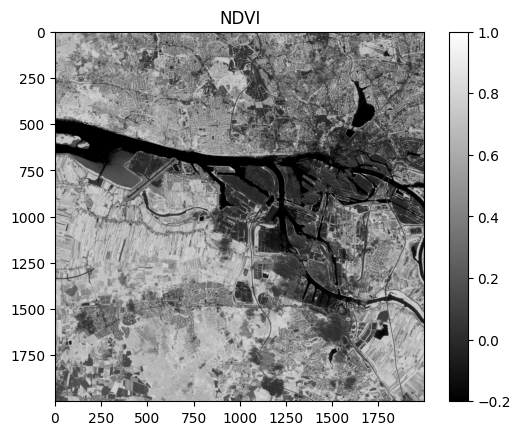

In [59]:
ndvi = ndvi_snapista_product.getBand('ndvi')
w = ndvi.getRasterWidth()
h = ndvi.getRasterHeight()

ndvi_data = np.zeros(w * h, np.float32)
ndvi.readPixels(0, 0, w, h, ndvi_data)
ndvi_data.shape = h, w

plot_ndvi(ndvi_data)

---

---

### ***Summary***

What have we learnt in this notebook?

- How to read a Sentinel-2 L1C product into SNAP
- How to alternatively use the Java-Python mapping provided by Snappy, use SNAP GPF operators with Snappy, or build and run a SNAP gpt graph using SNAP Python API 'SNAPISTA'